In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter

Загрузка данных

In [2]:
df = pd.read_csv('heart.csv')
print(f"Исходный размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

df_no_target = df.drop('target', axis=1)
print(f"После удаления 'target': {df_no_target.shape[0]} строк, {df_no_target.shape[1]} столбцов\n")

Исходный размер датасета: 303 строк, 14 столбцов
После удаления 'target': 303 строк, 13 столбцов



Количество образцов и атрибутов

In [3]:
n_samples = df_no_target.shape[0]
n_attributes = df_no_target.shape[1]

print(f"Количество образцов: {n_samples}")
print(f"Количество атрибутов: {n_attributes}\n")

Количество образцов: 303
Количество атрибутов: 13



Описание типов признаков

In [4]:
feature_types = {
    'age': ('Числовой', 'Дискретный', 'Возраст в годах'),
    'sex': ('Категориальный', 'Бинарный', 'Пол (0=Female, 1=Male)'),
    'cp': ('Категориальный', 'Ординальный', 'Тип боли в груди (4 значения)'),
    'trestbps': ('Числовой', 'Непрерывный', 'АД в покое, мм рт.ст.'),
    'chol': ('Числовой', 'Непрерывный', 'Холестерин, мг/дл'),
    'fbs': ('Категориальный', 'Бинарный', 'Сахар крови >120 мг/дл'),
    'restecg': ('Категориальный', 'Ординальный', 'Результаты ЭКГ (0,1,2)'),
    'thalach': ('Числовой', 'Непрерывный', 'Макс. ЧСС'),
    'exang': ('Категориальный', 'Бинарный', 'Стенокардия от нагрузки'),
    'oldpeak': ('Числовой', 'Непрерывный', 'Депрессия ST'),
    'slope': ('Категориальный', 'Ординальный', 'Наклон сегмента ST'),
    'ca': ('Числовой', 'Дискретный', 'Кол-во сосудов (0-3)'),
    'thal': ('Категориальный', 'Ординальный', 'Thal-статус')
}

print(f"{'Признак':<12} {'Тип':<15} {'Подтип':<15} {'Описание'}")
print("-" * 80)
for feature, (ftype, subtype, desc) in feature_types.items():
    print(f"{feature:<12} {ftype:<15} {subtype:<15} {desc}")
print()

Признак      Тип             Подтип          Описание
--------------------------------------------------------------------------------
age          Числовой        Дискретный      Возраст в годах
sex          Категориальный  Бинарный        Пол (0=Female, 1=Male)
cp           Категориальный  Ординальный     Тип боли в груди (4 значения)
trestbps     Числовой        Непрерывный     АД в покое, мм рт.ст.
chol         Числовой        Непрерывный     Холестерин, мг/дл
fbs          Категориальный  Бинарный        Сахар крови >120 мг/дл
restecg      Категориальный  Ординальный     Результаты ЭКГ (0,1,2)
thalach      Числовой        Непрерывный     Макс. ЧСС
exang        Категориальный  Бинарный        Стенокардия от нагрузки
oldpeak      Числовой        Непрерывный     Депрессия ST
slope        Категориальный  Ординальный     Наклон сегмента ST
ca           Числовой        Дискретный      Кол-во сосудов (0-3)
thal         Категориальный  Ординальный     Thal-статус



Распределение мужчин/женщин в датасете

In [5]:
sex_counts = df_no_target['sex'].value_counts().sort_index()
n_female = sex_counts[0]
n_male = sex_counts[1]

print(f"Женщин (sex=0): {n_female} ({n_female/n_samples*100:.1f}%)")
print(f"Мужчин (sex=1): {n_male} ({n_male/n_samples*100:.1f}%)\n")

Женщин (sex=0): 96 (31.7%)
Мужчин (sex=1): 207 (68.3%)



Описательные статистики для количественных признаков

In [6]:
def calculate_descriptive_stats(data, column_name):
    data = data.dropna()
    n = len(data)
    
    mean_val = np.mean(data)
    median_val = np.median(data)
    
    mode_result = stats.mode(data, keepdims=True)
    mode_val = mode_result.mode[0] if hasattr(mode_result, 'mode') else mode_result[0][0]
    
    data_min = np.min(data)
    data_max = np.max(data)
    range_val = data_max - data_min
    
    variance_val = np.var(data, ddof=1)
    std_val = np.std(data, ddof=1)
    
    q1 = np.percentile(data, 25)
    q2 = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    
    iqr = q3 - q1
    
    stats_dict = {
        'column': column_name,
        'count': n,
        'mean': mean_val,
        'median': median_val,
        'mode': mode_val,
        'min': data_min,
        'max': data_max,
        'range': range_val,
        'variance': variance_val,
        'std': std_val,
        'q1': q1,
        'q2': q2,
        'q3': q3,
        'iqr': iqr
    }
    
    return stats_dict

quantitative_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

print(f"{'Признак':<12} {'Среднее':>10} {'Медиана':>10} {'Мода':>8} {'Стд.откл.':>12} {'IQR':>10}")
print("-" * 80)

all_stats = {}
for feature in quantitative_features:
    stats_result = calculate_descriptive_stats(df_no_target[feature], feature)
    all_stats[feature] = stats_result
    print(f"{feature:<12} {stats_result['mean']:>10.2f} {stats_result['median']:>10.2f} "
          f"{stats_result['mode']:>8.1f} {stats_result['std']:>12.2f} {stats_result['iqr']:>10.2f}")
print()

Признак         Среднее    Медиана     Мода    Стд.откл.        IQR
--------------------------------------------------------------------------------
age               54.37      55.00     58.0         9.08      13.50
trestbps         131.62     130.00    120.0        17.54      20.00
chol             246.26     240.00    197.0        51.83      63.50
thalach          149.65     153.00    162.0        22.91      32.50
oldpeak            1.04       0.80      0.0         1.16       1.60
ca                 0.73       0.00      0.0         1.02       1.00



Категориальные признаки - столбчатые диаграммы

sex: {0: np.int64(96), 1: np.int64(207)}
cp: {0: np.int64(143), 1: np.int64(50), 2: np.int64(87), 3: np.int64(23)}
fbs: {0: np.int64(258), 1: np.int64(45)}
restecg: {0: np.int64(147), 1: np.int64(152), 2: np.int64(4)}
exang: {0: np.int64(204), 1: np.int64(99)}
slope: {0: np.int64(21), 1: np.int64(140), 2: np.int64(142)}
thal: {0: np.int64(2), 1: np.int64(18), 2: np.int64(166), 3: np.int64(117)}


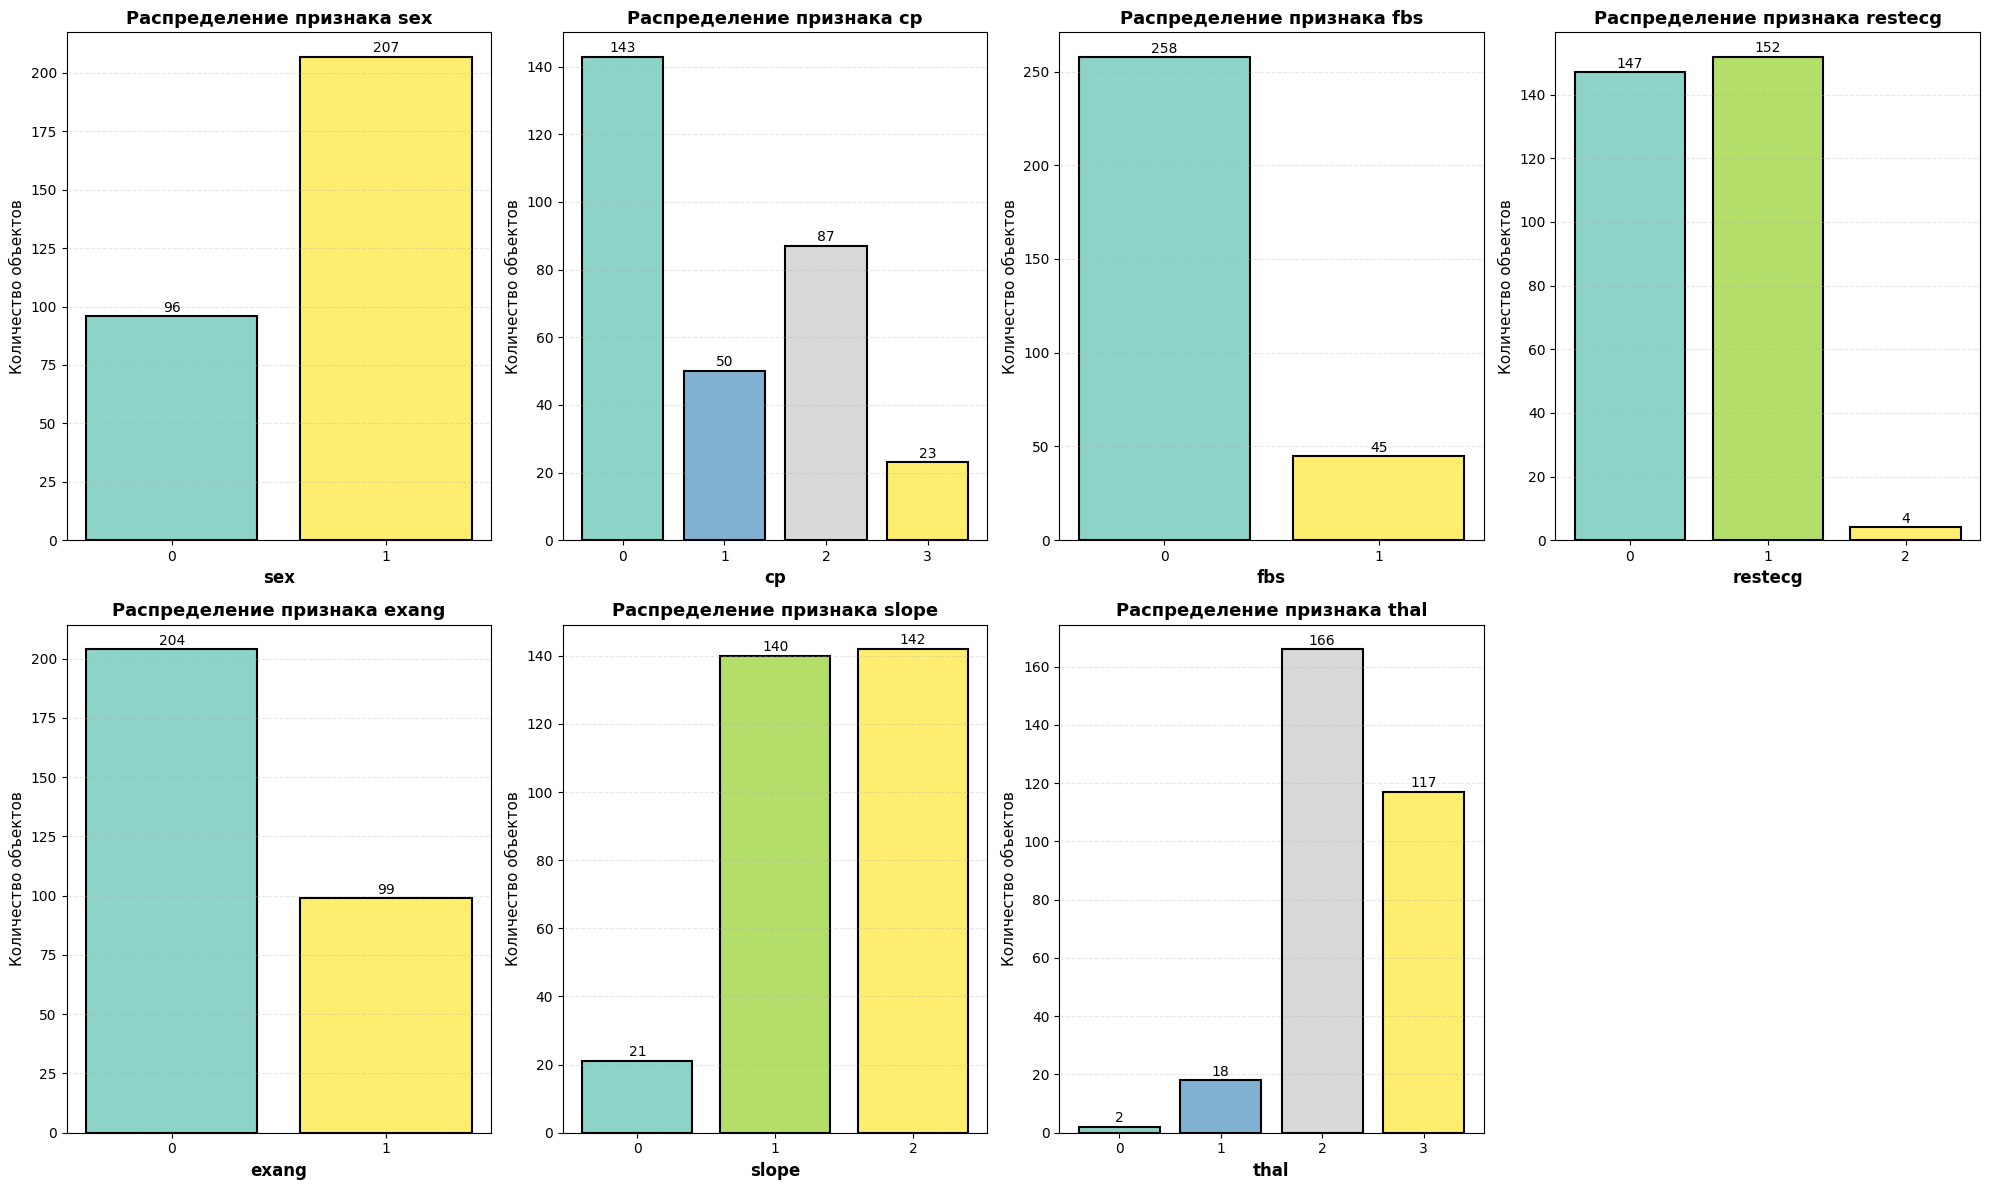

In [ ]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    value_counts = df_no_target[feature].value_counts().sort_index()
    
    axes[idx].bar(value_counts.index.astype(str), value_counts.values, 
                  color=plt.cm.Set3(np.linspace(0, 1, len(value_counts))), 
                  edgecolor='black', linewidth=1.5)
    axes[idx].set_xlabel(feature, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Количество объектов', fontsize=11)
    axes[idx].set_title(f'Распределение признака {feature}', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)
    
    print(f"{feature}: {dict(value_counts)}")

axes[7].set_visible(False)

plt.tight_layout()
# plt.savefig('categorical_bar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

Гистограммы для количественных признаков

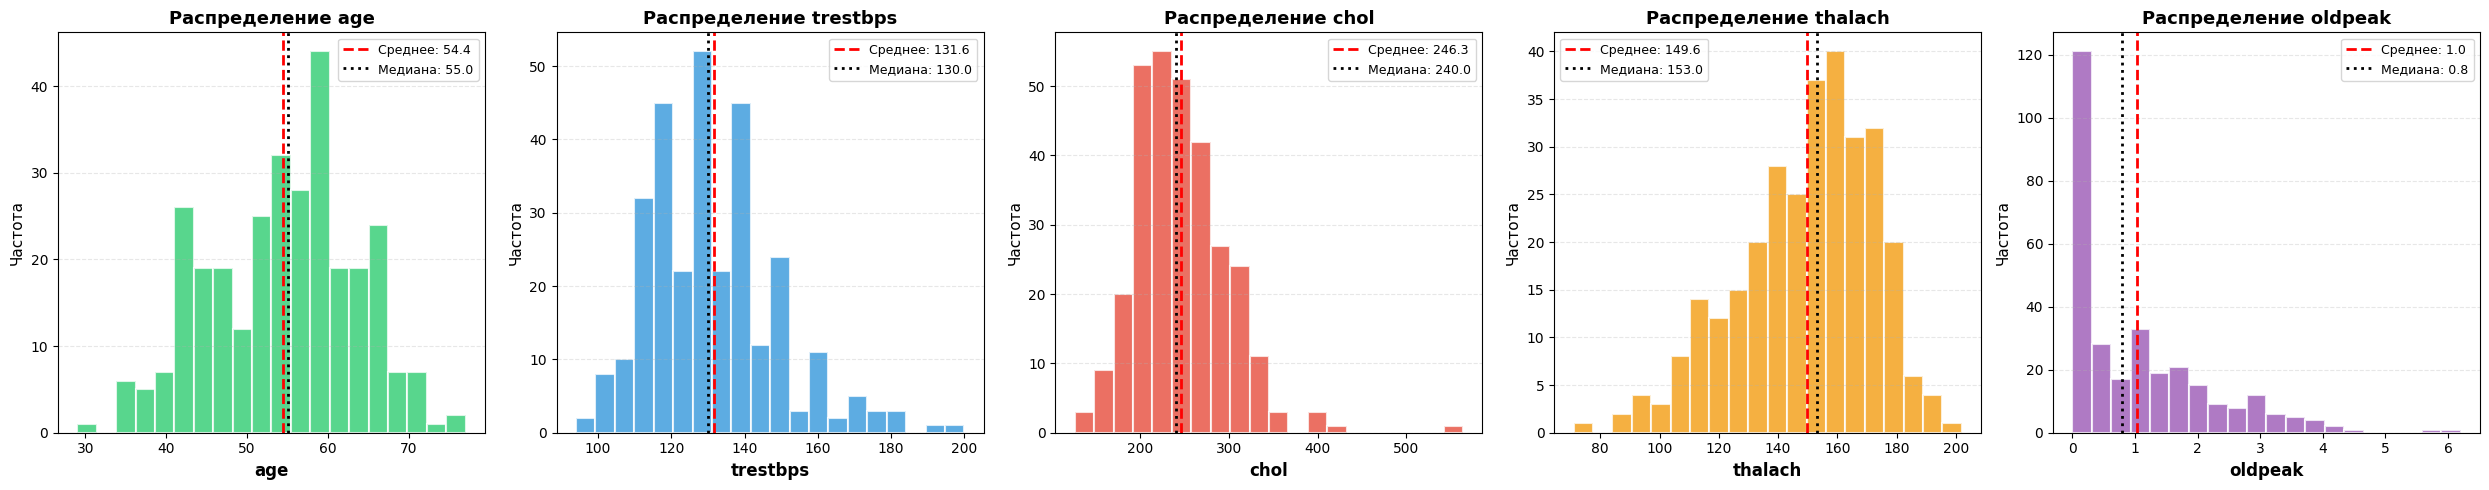

In [ ]:
hist_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, (feature, color) in enumerate(zip(hist_features, colors)):
    data = df_no_target[feature]
    axes[idx].hist(data, bins=20, color=color, edgecolor='white', linewidth=1.5, alpha=0.8)
    axes[idx].set_xlabel(feature, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Частота', fontsize=11)
    axes[idx].set_title(f'Распределение {feature}', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    mean_val = np.mean(data)
    median_val = np.median(data)
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='black', linestyle=':', linewidth=2, label=f'Медиана: {median_val:.1f}')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
# plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()

 "Ящики с усами" для признаков age, trestbps, chol, thalach, oldpeak

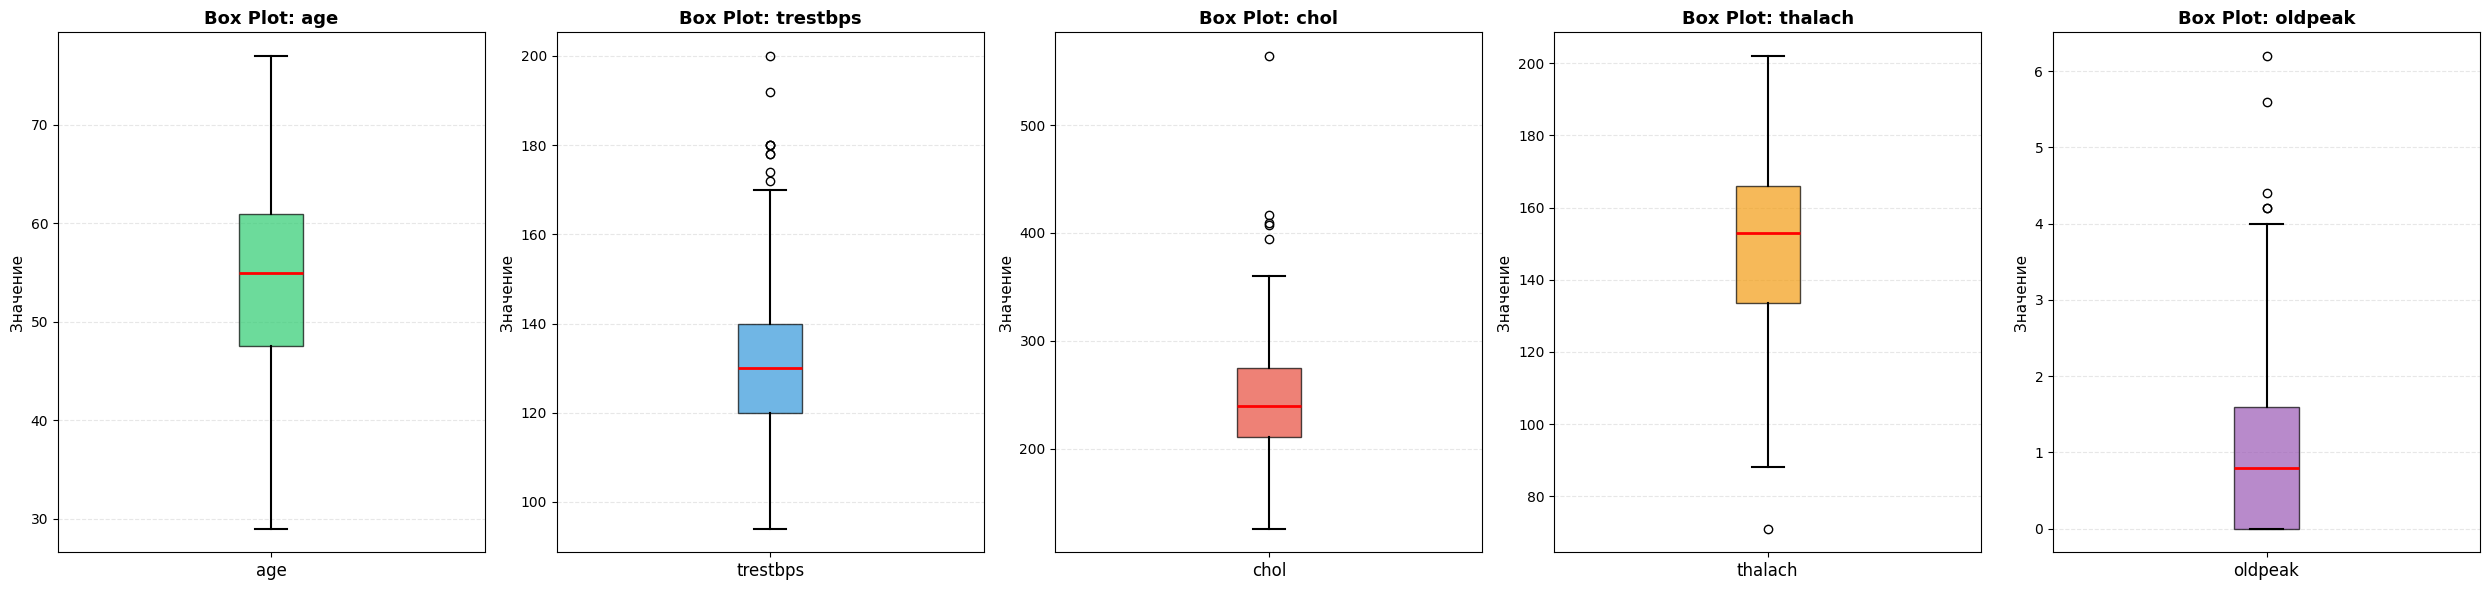

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for idx, feature in enumerate(hist_features):
    data = df_no_target[feature]
    bp = axes[idx].boxplot(data, patch_artist=True, 
                           boxprops=dict(facecolor=colors[idx], alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           whiskerprops=dict(color='black', linewidth=1.5),
                           capprops=dict(color='black', linewidth=1.5))
    
    axes[idx].set_ylabel('Значение', fontsize=11)
    axes[idx].set_title(f'Box Plot: {feature}', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].set_xticklabels([feature], fontsize=12)

plt.tight_layout()
# plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

PDF (probability density function) для признака chol

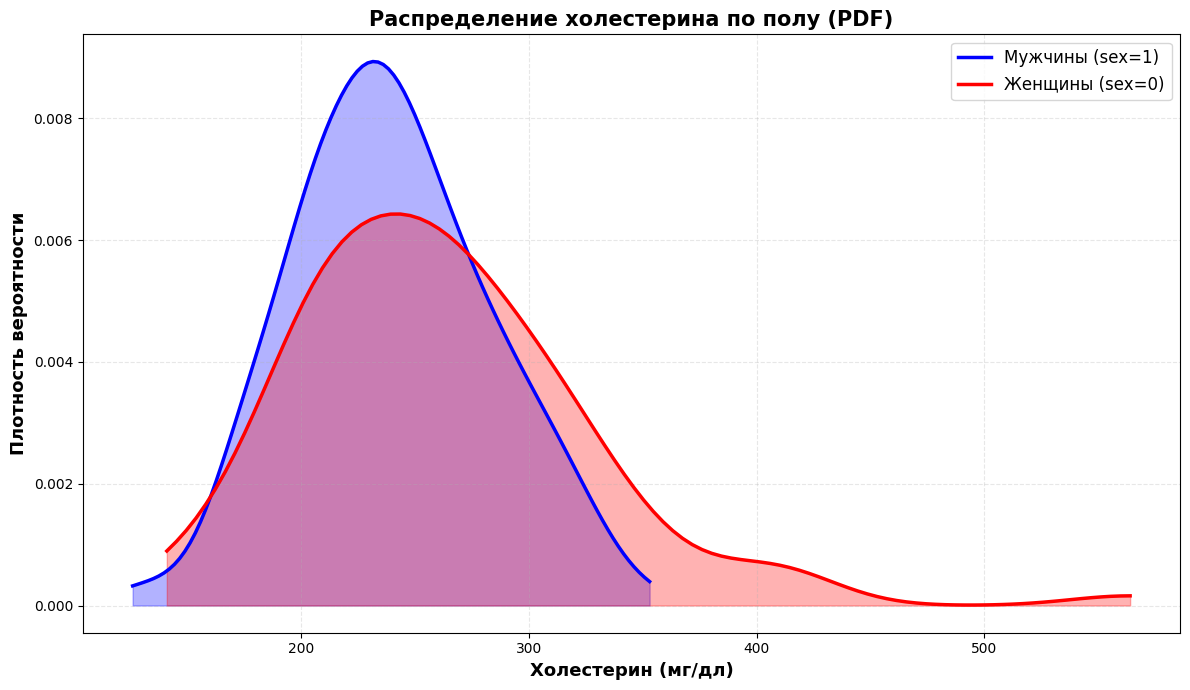

Холестерин - Мужчины: среднее = 239.29, стд = 42.68
Холестерин - Женщины: среднее = 261.30, стд = 64.75



In [ ]:
chol_male = df_no_target[df_no_target['sex'] == 1]['chol']
chol_female = df_no_target[df_no_target['sex'] == 0]['chol']

fig, ax = plt.subplots(figsize=(12, 7))

kde_male = stats.gaussian_kde(chol_male)
x_male = np.linspace(chol_male.min(), chol_male.max(), 100)
ax.plot(x_male, kde_male(x_male), color='blue', linewidth=2.5, label='Мужчины (sex=1)')
ax.fill_between(x_male, kde_male(x_male), alpha=0.3, color='blue')

kde_female = stats.gaussian_kde(chol_female)
x_female = np.linspace(chol_female.min(), chol_female.max(), 100)
ax.plot(x_female, kde_female(x_female), color='red', linewidth=2.5, label='Женщины (sex=0)')
ax.fill_between(x_female, kde_female(x_female), alpha=0.3, color='red')

ax.set_xlabel('Холестерин (мг/дл)', fontsize=13, fontweight='bold')
ax.set_ylabel('Плотность вероятности', fontsize=13, fontweight='bold')
ax.set_title('Распределение холестерина по полу (PDF)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig('chol_pdf_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Холестерин - Мужчины: среднее = {np.mean(chol_male):.2f}, стд = {np.std(chol_male):.2f}")
print(f"Холестерин - Женщины: среднее = {np.mean(chol_female):.2f}, стд = {np.std(chol_female):.2f}\n")

Вычисление для каждой группы среднего значения признака chol

           mean        std  count
sex                              
0    261.302083  65.088946     96
1    239.289855  42.782392    207


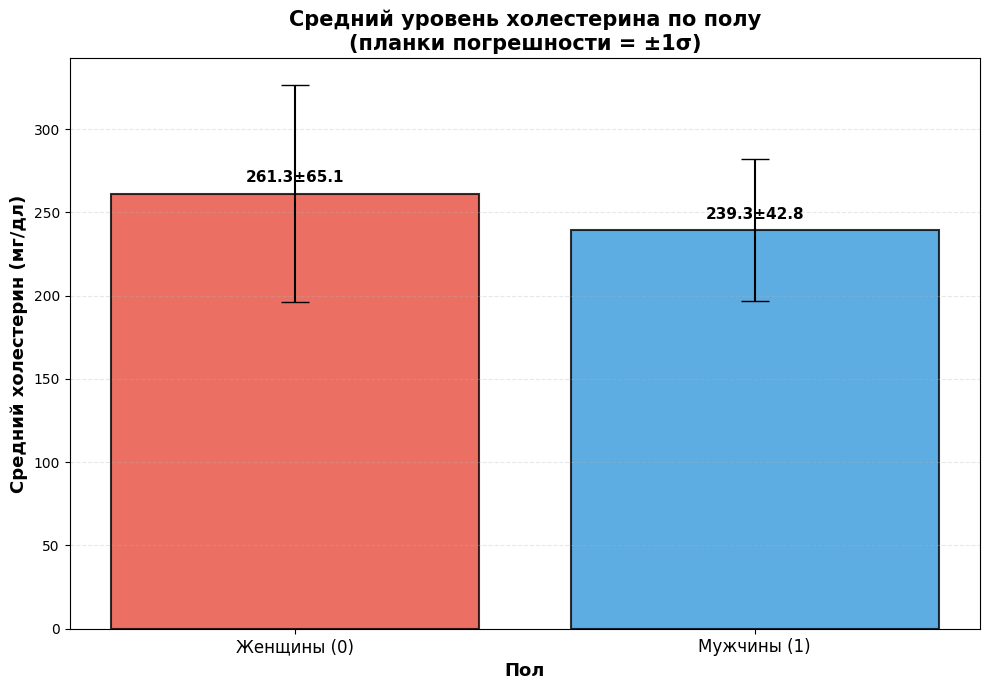

In [ ]:
chol_grouped = df_no_target.groupby('sex')['chol'].agg(['mean', 'std', 'count'])
print(chol_grouped)

fig, ax = plt.subplots(figsize=(10, 7))

sex_labels = ['Женщины (0)', 'Мужчины (1)']
x_pos = [0, 1]
means = chol_grouped['mean'].values
stds = chol_grouped['std'].values

bars = ax.bar(x_pos, means, yerr=stds, capsize=10, 
              color=['#e74c3c', '#3498db'], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Пол', fontsize=13, fontweight='bold')
ax.set_ylabel('Средний холестерин (мг/дл)', fontsize=13, fontweight='bold')
ax.set_title('Средний уровень холестерина по полу\n(планки погрешности = ±1σ)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(sex_labels, fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{mean:.1f}±{std:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
# plt.savefig('chol_mean_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()

Выводы:
1. ОБЪЁМ ДАННЫХ:
   - Датасет содержит 303 образца с 13 признаками (после удаления target)

2. ГЕНДЕРНЫЙ БАЛАНС:
   - Мужчин значительно больше (68.3%), чем женщин (31.7%)
   - Дисбаланс может повлиять на качество моделей классификации
   - Рекомендуется использовать техники балансировки при обучении

3. ВОЗРАСТНОЕ РАСПРЕДЕЛЕНИЕ:
   - Возраст: 29-77 лет, среднее = 54.4 года
   - Большинство рецензентов в возрасте 50-60 лет
   - IQR = 13.5 лет указывает на умеренный разброс

4. ХОЛЕСТЕРИН:
   - Средний уровень: 246.3 мг/дл (медиана = 240)
   - У женщин средний холестерин выше (261.3 мг/дл), чем у мужчин (239.3 мг/дл)
   - Высокий разброс (std = 51.8) указывает на разнообразие пациентов
   - Присутствуют выбросы (максимум = 564 мг/дл)

5. АРТЕРИАЛЬНОЕ ДАВЛЕНИЕ:
   - trestbps: среднее = 131.6 мм рт.ст.
   - Нормальное распределение с умеренным разбросом

6. МАКСИМАЛЬНАЯ ЧСС:
   - thalach: среднее = 149.7, медиана = 153
   - Отрицательная асимметрия (медиана > среднего)

7. ДЕПРЕССИЯ ST:
   - oldpeak: среднее = 1.04, много нулевых значений
   - Положительная асимметрия распределения

8. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:
   - cp (тип боли): 4 категории, неравномерное распределение
   - slope: 3 категории, преобладает значение 2
   - thal: 3 категории, значение 2 наиболее частое
   - ca: 0-3 сосуда, большинство = 0

9. КАЧЕСТВО ДАННЫХ:
   - Отсутствуют пропущенные значения
   - Присутствуют потенциальные выбросы (chol, thalach, oldpeak)
   - Требуется дополнительная проверка аномальных значений